#### Subjects
 - 50000R
 - 50017L
 - 50034R
#### Parameters
 - 1.5 layars of T10's
 - d0 = 5
#### Poses
 - Flexion
 - Extension
 - abduction
 - adduction
 - pinch load
#### End criteria
 - 0.8 mm
 - 50 N

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from phd_helpers.AbaqusPostprocessing import (
    inp2pv, get_field_path, get_field_df, add_field_to_mesh, parse_wallclock_time, parse_final_step_time, get_history_path
)
from phd_helpers.AbaqusPreprocessing import parse_memory_estimate

In [39]:
DIR = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/poses_d5CAsubs')

bones = ['tpm']
subjects = ['50000R']#, '50017L', '50034R']
ids = [
    ('d5', '0'), # (run_id_mesh, run_id)
    ]
poses = ['flexion', 'extension', 'abduction', 'adduction', 'pinch_load']
step = 0
frame = -1

field_metrics = ["CPRESS", "U"]


data = []
for subject in subjects:
    for bone in bones:
        instance = f"{bone.upper()}_INST"
        for pose in poses:
            for run_id_mesh, run_id in ids:
                job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

                path_inp = DIR / f'inpFiles/{subject}/inp'
                path_job = path_inp / job_name
                path_csv = path_job / 'resultCSVs'
                input_path = path_job / job_name.with_suffix('.inp')
                dat_path = path_job / job_name.with_suffix('.dat')
                sta_path = path_job / job_name.with_suffix('.sta')

                # RESULTS #
                meshes = inp2pv(input_path)
                mesh = meshes[bone]

                # Field data
                for metric in field_metrics:
                    field_path = get_field_path(path_csv, metric, step, frame, instance)
                    field_df = get_field_df(field_path)
                    add_field_to_mesh(mesh, field_df)
                mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

                # History data
                history_data = pd.read_csv(get_history_path(path_csv, step))
                RF_data = history_data[history_data['historyOutputKey']=='RF1']
                CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']


                data.append({
                    'subject': subject,
                    'job': job_name,
                    'P': mesh['CPRESS'].max(),
                    'A': CAREA_data['value'].iloc[frame],
                    'F' : np.abs(RF_data['value'].iloc[frame]),
                    'd' : parse_final_step_time(sta_path),
                    'nodes' : mesh.n_points,
                    'elements' : mesh.n_cells,
                    'memory' : parse_memory_estimate(dat_path)['memory_to_minimize_io_gb'],
                    'runtime' : parse_wallclock_time(dat_path),
                })

df = pd.DataFrame(data)

In [40]:
get_deformed_mesh(mesh).plot(scalars="CPRESS", cmap='Accent_r')

Widget(value='<iframe src="http://localhost:54286/index.html?ui=P_0x35d5f2ae0_11&reconnect=auto" class="pyvist…

In [8]:
df

,subject,job,P,A,F,d,nodes,elements,memory,runtime
0,50000R,d5-flexion-0,2.825066,56.927898,49.970608,0.140,84193,57027,9.727,2153.0
1,50000R,d5-extension-0,1.978922,42.436710,34.708260,0.203,84193,57027,9.725,5544.0
2,50000R,d5-abduction-0,3.535621,50.648445,49.999218,0.192,84193,57027,9.726,4110.0
3,50000R,d5-adduction-0,3.134415,52.926769,47.974667,0.597,84193,57027,9.723,8413.0
4,50000R,d5-pinch_load-0,3.832304,37.547939,34.208389,0.283,84193,57027,9.725,7162.0


# Plan:
tweak params for extension (50000R) - find robustest ones
### Study 1
 - Loop over:
    - max step
    - extrapolation
    - convert_sdi
    - friction
    - hybrid modified

    - stabilisation ?
    - Contact normal behavior ?
### Study 2
 - Run best (30) params but with C3D10M bone elements with and without stabilisation
 - Were also unintentionally compressible D1=0.02
### Study 3
 - higher stabilise factors
 - D1 = [0, 0.02]
 - friction= [0.1, 0.0]

In [42]:
#mesh_path = '../../../../Computational/MeshPipeline/outputs/ParamOptimisation/optimise_d0/d5best'
import subprocess
inpMain_path = '../../../../Computational/InpPipeline/main.py'
subprocess.run(['python', inpMain_path])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/inpPipeline/set_parameters/parameters.json
Full parameter file saved to outputs/tweak_50000R_ext/study3-inp/params/full_params.json

SUBJECT: 50000R
	MESH: d5
		RUN ID: 00
			Runtime: 10.422s - ok
		RUN ID: 01
			Runtime: 10.251s - ok
		RUN ID: 02
			Runtime: 10.229s - ok
		RUN ID: 03
			Runtime: 10.262s - ok
		RUN ID: 04
			Runtime: 10.254s - ok
		RUN ID: 05
			Runtime: 10.277s - ok
		RUN ID: 06
			Runtime: 10.243s - ok
		RUN ID: 07
			Runtime: 10.239s - ok


CompletedProcess(args=['python', '../../../../Computational/InpPipeline/main.py'], returncode=0)

In [82]:
DIR = Path('outputs/tweak_50000R_ext')
studies = [1, 2]

bones = ['tpm']
subjects = ['50000R']#, '50017L', '50034R']

poses = ['extension']
step = 0
frame = -1

field_metrics = ["CPRESS", "U"]


data = []
for study in studies:
    for subject in subjects:
        for bone in bones:
            instance = f"{bone.upper()}_INST"
            for pose in poses:
                study_dir = DIR / f'study{study}-inp'
                ids = [ ('d5', f'{x:02}') for x in range(len(list(study_dir.glob('**/params/loop_params/*.json')))) ]
                for run_id_mesh, run_id in ids:
                    job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

                    path_inp = study_dir / f'inpFiles/{subject}/inp'
                    path_job = path_inp / job_name
                    path_csv = path_job / 'resultCSVs'
                    input_path = path_job / job_name.with_suffix('.inp')
                    dat_path = path_job / job_name.with_suffix('.dat')
                    sta_path = path_job / job_name.with_suffix('.sta')

                    # RESULTS #
                    meshes = inp2pv(input_path)
                    mesh = meshes[bone]

                    # Field data
                    for metric in field_metrics:
                        field_path = get_field_path(path_csv, metric, step, frame, instance)
                        field_df = get_field_df(field_path)
                        add_field_to_mesh(mesh, field_df)
                    mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

                    # History data
                    history_data = pd.read_csv(get_history_path(path_csv, step))
                    RF_data = history_data[history_data['historyOutputKey']=='RF1']
                    CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']

                    with open(study_dir / f'params/loop_params/{run_id}.json', 'r') as f:
                        params = json.load(f)

                    data.append({
                        'study': study,
                        'subject': subject,
                        'run_id': run_id,
                        'P': mesh['CPRESS'].max(),
                        'A': CAREA_data['value'].iloc[frame],
                        'F' : np.abs(RF_data['value'].iloc[frame]),
                        'd' : parse_final_step_time(sta_path),
                        'nodes' : mesh.n_points,
                        'elements' : mesh.n_cells,
                        'memory' : parse_memory_estimate(dat_path)['memory_to_minimize_io_gb'],
                        'runtime' : parse_wallclock_time(dat_path),
                        'element_type': params['element_type']+params['cartilage_element_suffix'],
                        'friction': params['cartilage_friction'],
                        'D1': params['cartilage_material']['D1'],
                        'max_increment': params['max_increment'],
                        'convert_sdi': params['convert_sdi'],
                        'extrapolation': 'LINEAR' if params['extrapolation'] is None else params['extrapolation'],
                        'stabilise_factor': params['stabilize_factor'] if params.get('stabilize', False) else False,
                    })

df = pd.DataFrame(data)

In [83]:
df.sort_values('d')

,study,subject,run_id,P,A,F,d,nodes,elements,memory,runtime,element_type,friction,D1,max_increment,convert_sdi,extrapolation,stabilise_factor
12,1,50000R,12,1.903232,41.501637,32.272739,0.188,84193,57027,9.725,5476.0,C3D10H,0.01,0.00,0.010,NO,LINEAR,False
15,1,50000R,15,1.903232,41.501637,32.272739,0.188,84193,57027,9.725,5092.0,C3D10H,0.01,0.00,0.010,YES,NO,False
14,1,50000R,14,1.903232,41.501637,32.272739,0.188,84193,57027,9.725,4955.0,C3D10H,0.01,0.00,0.010,YES,LINEAR,False
13,1,50000R,13,1.903232,41.501637,32.272739,0.188,84193,57027,9.725,5141.0,C3D10H,0.01,0.00,0.010,NO,NO,False
11,1,50000R,11,1.924657,41.750450,32.755714,0.189,84193,57027,9.725,2594.0,C3D10H,0.01,0.00,0.025,YES,NO,False
10,1,50000R,10,1.924658,41.750446,32.755714,0.189,84193,57027,9.725,2512.0,C3D10H,0.01,0.00,0.025,YES,LINEAR,False
9,1,50000R,09,1.924657,41.750450,32.755714,0.189,84193,57027,9.725,2517.0,C3D10H,0.01,0.00,0.025,NO,NO,False
8,1,50000R,08,1.924658,41.750446,32.755714,0.189,84193,57027,9.725,2312.0,C3D10H,0.01,0.00,0.025,NO,LINEAR,False
0,1,50000R,00,1.971924,42.397766,34.533836,0.193,84193,57027,9.725,3168.0,C3D10H,0.00,0.00,0.025,NO,LINEAR,False
6,1,50000R,06,1.961177,42.304207,34.266556,0.193,84193,57027,9.725,3597.0,C3D10H,0.00,0.00,0.010,YES,LINEAR,False


# Modified elements are not compatible with regular elements if they share nodes
 - All the above study1 MH were done with regular C3D10 bone elements and C3D10MH cartilage elements
 - Running study2 with C3D10M bone elements and C3D10MH cartilage elements

In [ ]:
- lower max increment

## Load mesh and data

In [ ]:
run_id = '03'
study = 'study3'

DIR = Path(f'outputs/tweak_50000R_ext/{study}-inp')
bone = 'tpm'
subject = '50000R' #, '50017L', '50034R']
run_id_mesh = 'd5'
pose = 'extension'
step = 0
frame = -1
instance = f"{bone.upper()}_INST"
field_metrics = ["CPRESS", "U"]

job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

path_inp = DIR / f'inpFiles/{subject}/inp'
path_job = path_inp / job_name
path_csv = path_job / 'resultCSVs'
input_path = path_job / job_name.with_suffix('.inp')

# RESULTS #
meshes = inp2pv(input_path)
mesh = meshes[bone]

# Field data
for metric in field_metrics:
    field_path = get_field_path(path_csv, metric, step, frame, instance)
    field_df = get_field_df(field_path)
    add_field_to_mesh(mesh, field_df)
mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)
#mesh['VFmag'] = np.linalg.norm(np.column_stack((mesh['VF1'], mesh['VF2'], mesh['VF3'])), axis=1)

# History data
history_data = pd.read_csv(get_history_path(path_csv, step))
RF_data = history_data[history_data['historyOutputKey']=='RF1']
CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
allie = history_data[history_data['historyOutputKey']=='ALLIE'] # internal energy
allsd = history_data[history_data['historyOutputKey']=='ALLSD'] # Static dissipation

### Looks like surface wrinkling
- Try stabilisation: https://docs.software.vt.edu/abaqusv2024/English/SIMACAEANLRefMap/simaanl-c-static.htm
---
- MH elements cause surface wrinkling, H not so much

In [79]:
from phd_helpers.AbaqusPostprocessing import get_deformed_mesh
import pyvista as pv


pl = pv.Plotter()
pl.add_mesh(get_deformed_mesh(mesh), scalars='CPRESS', cmap='Accent_r', opacity=1)

bad_element = 62699 # abaqus indexes from 1
#ab_id = mesh['abaqus_element_id'][bad_element]
#pl.add_points(mesh.points[mesh.cells.reshape(-1, 11)[:, 1:][bad_element]], color='cyan', point_size=10)
pl.show()

Widget(value='<iframe src="http://localhost:54286/index.html?ui=P_0x35cdc6630_23&reconnect=auto" class="pyvist…

In [86]:
RF_data['value'].min()

np.float64(-34.84939956665039)

/var/folders/md/chz9snx91svc73k94gsj2m7m0000gn/T/ipykernel_14244/683601099.py:5: RuntimeWarning: invalid value encountered in divide
  ax.plot(allsd['time'], allsd['value'].values/allie['value'].values)


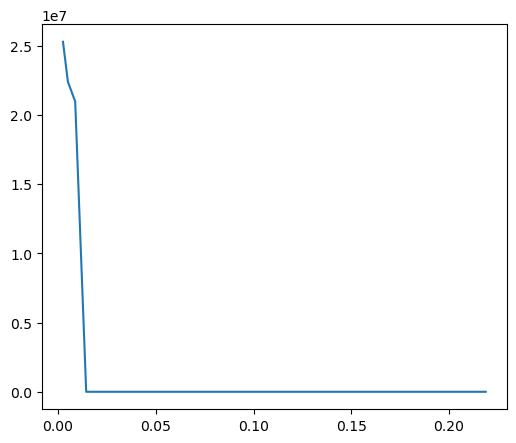

In [56]:
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))

#ax.plot(allie['time'], allie['value'])
ax.plot(allsd['time'], allsd['value'].values/allie['value'].values)

### Study 4
 - stabilise = 1
 - element type = [H, MH]
 - D1 = 0
 - friction = 0.01

### Study 5
 - pressure-overclosure
 - SMALL SLIDING
 - H, MH

look at slightly softened pressure-overclosure law
look at contact dampening